<a href="https://colab.research.google.com/github/Juyoung-Industrial-Innovation-Team/swin-yolo26-paint-defect/blob/main/notebooks/08_Co-Sight_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,Model,mAP@50,mAP@50-95
0,YOLO11,0.87772,0.70716
1,YOLO26,0.89328,0.74710
2,SwinYOLO26,0.38264,0.17032


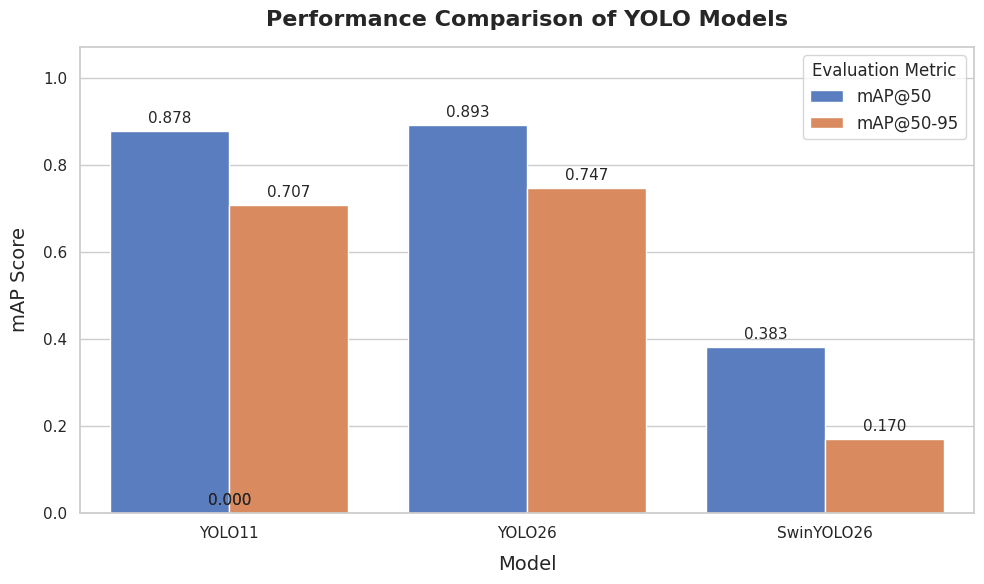

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 파일 경로 및 모델명 매핑
files = {
    'YOLO11': '/content/yolo11results.csv',
    'YOLO26': '/content/yolo26results.csv',
    'SwinYOLO26': '/content/swinyolo26results.csv'
}

best_metrics = []

for model_name, path in files.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        # YOLO CSV는 컬럼명에 공백이 포함되는 경우가 많아 공백 제거
        df.columns = df.columns.str.strip()

        # 일반적인 YOLO 평가지표 컬럼명 (mAP50, mAP50-95)
        # 버전에 따라 컬럼명이 다를 수 있으므로 포함 여부 확인 후 최대값(best epoch) 추출
        map50_col = [c for c in df.columns if 'mAP50' in c and '95' not in c]
        map50_95_col = [c for c in df.columns if 'mAP50-95' in c or 'mAP_0.5:0.95' in c]

        map50_val = df[map50_col[0]].max() if map50_col else 0
        map50_95_val = df[map50_95_col[0]].max() if map50_95_col else 0

        best_metrics.append({
            'Model': model_name,
            'mAP@50': map50_val,
            'mAP@50-95': map50_95_val
        })
    else:
        print(f"File not found: {path}")

# 데이터프레임 변환 및 확인
results_df = pd.DataFrame(best_metrics)
display(results_df)

# 논문용 그래프 설정 및 시각화
if not results_df.empty:
    # Seaborn 스타일 설정 (논문용 깔끔한 스타일)
    sns.set_theme(style="whitegrid")

    # 데이터를 Seaborn 막대 그래프에 맞게 형태 변환 (melt)
    df_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted, palette='muted')

    # 논문용 제목 및 축 라벨 설정
    plt.title('Performance Comparison of YOLO Models', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Model', fontsize=14, labelpad=10)
    plt.ylabel('mAP Score', fontsize=14, labelpad=10)

    # y축 범위 설정 (값이 0~1 사이라면 0~1.0, 0~100 사이라면 0~100으로 설정)
    # 여기서는 값이 0~1 사이일 것으로 가정하고 여유 있게 범위를 잡습니다.
    max_score = df_melted['Score'].max()
    plt.ylim(0, max_score * 1.2 if max_score > 0 else 1.0)

    # 막대 위에 수치 텍스트 표시
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.3f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points',
                    fontsize=11)

    plt.legend(title='Evaluation Metric', fontsize=12, title_fontsize=12)
    plt.tight_layout()
    plt.show()


,Model,Precision,Recall,mAP@50,mAP@50-95
0,YOLO11,0.86118,0.86604,0.87542,0.70716
1,YOLO26,0.88009,0.87701,0.89277,0.74710
2,SwinYOLO26,0.49800,0.49273,0.37902,0.17032


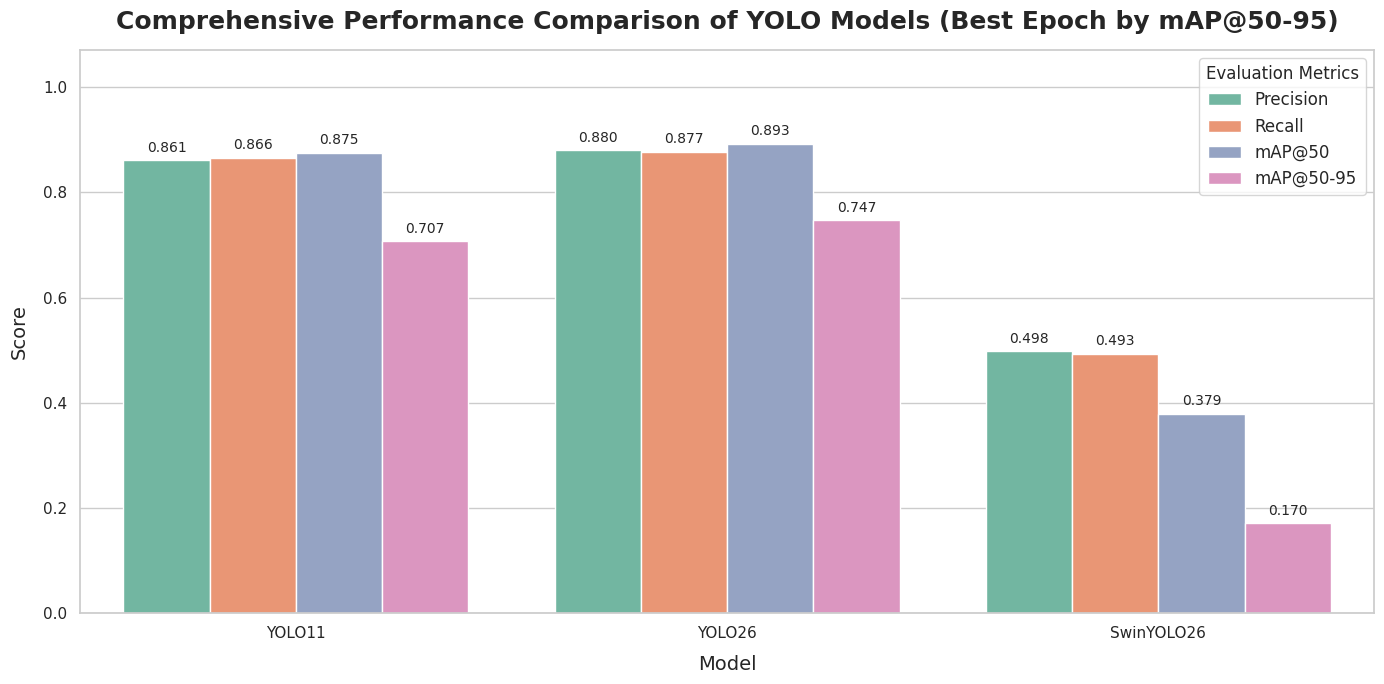

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 파일 경로 및 모델명 매핑
files = {
    'YOLO11': '/content/yolo11results.csv',
    'YOLO26': '/content/yolo26results.csv',
    'SwinYOLO26': '/content/swinyolo26results.csv'
}

all_metrics = []

for model_name, path in files.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()

        # 주요 평가지표 컬럼 찾기 (대소문자 및 포맷 차이 고려)
        p_col = [c for c in df.columns if 'precision' in c.lower() or 'metrics/p' in c]
        r_col = [c for c in df.columns if 'recall' in c.lower() or 'metrics/r' in c]
        map50_col = [c for c in df.columns if 'map50' in c.lower() and '95' not in c]
        map50_95_col = [c for c in df.columns if 'map50-95' in c.lower() or '0.5:0.95' in c]

        # 논문 표준 방식: mAP@50-95 가 가장 높은 Epoch(Best Epoch)를 찾아 해당 시점의 모든 지표 추출
        if map50_95_col:
            best_epoch_idx = df[map50_95_col[0]].idxmax()

            p_val = df.loc[best_epoch_idx, p_col[0]] if p_col else 0
            r_val = df.loc[best_epoch_idx, r_col[0]] if r_col else 0
            map50_val = df.loc[best_epoch_idx, map50_col[0]] if map50_col else 0
            map50_95_val = df.loc[best_epoch_idx, map50_95_col[0]]
        else:
            # Fallback: 개별 최대값 (지표가 없는 경우 등 대비)
            p_val = df[p_col[0]].max() if p_col else 0
            r_val = df[r_col[0]].max() if r_col else 0
            map50_val = df[map50_col[0]].max() if map50_col else 0
            map50_95_val = 0

        all_metrics.append({
            'Model': model_name,
            'Precision': p_val,
            'Recall': r_val,
            'mAP@50': map50_val,
            'mAP@50-95': map50_95_val
        })

# 데이터프레임 변환 및 출력
extended_results_df = pd.DataFrame(all_metrics)
display(extended_results_df)

# 논문용 종합 그래프 시각화 (Grouped Bar Chart)
if not extended_results_df.empty:
    sns.set_theme(style="whitegrid")

    # 데이터를 Seaborn에 맞게 melt
    df_melted_ext = extended_results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

    plt.figure(figsize=(14, 7))
    # 색상 팔레트 변경 (Set2 등 가독성 좋은 색상 사용)
    ax = sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted_ext, palette='Set2')

    plt.title('Comprehensive Performance Comparison of YOLO Models (Best Epoch by mAP@50-95)', fontsize=18, fontweight='bold', pad=15)
    plt.xlabel('Model', fontsize=14, labelpad=10)
    plt.ylabel('Score', fontsize=14, labelpad=10)

    max_score = df_melted_ext['Score'].max()
    plt.ylim(0, max_score * 1.2 if max_score > 0 else 1.0)

    # 막대 위에 수치 텍스트 표시
    for p in ax.patches:
        height = p.get_height()
        if height > 0: # 0이 아닌 값만 표시
            ax.annotate(format(height, '.3f'),
                        (p.get_x() + p.get_width() / 2., height),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points',
                        fontsize=10)

    # 범례 위치 조정
    plt.legend(title='Evaluation Metrics', fontsize=12, title_fontsize=12, loc='upper right')
    plt.tight_layout()
    plt.show()

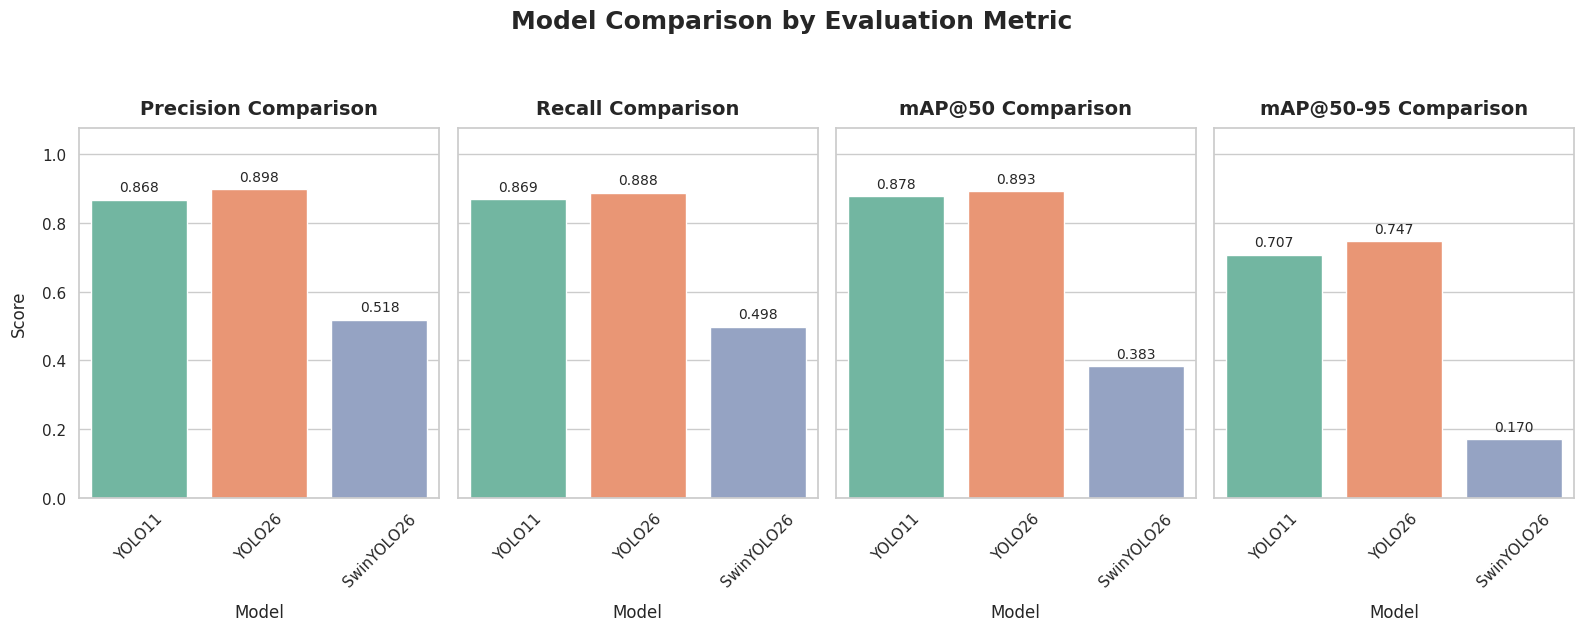

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 이전 셀에서 만들어진 extended_results_df를 활용
if 'extended_results_df' in locals() and not extended_results_df.empty:
    sns.set_theme(style="whitegrid")

    # 이번에는 평가지표(Metric)를 기준으로 데이터를 나눔
    df_melted_ext = extended_results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
    metrics = df_melted_ext['Metric'].unique()
    num_metrics = len(metrics)

    # 평가지표 수에 맞춰 서브플롯 생성
    fig, axes = plt.subplots(1, num_metrics, figsize=(4 * num_metrics, 6), sharey=True)

    if num_metrics == 1:
        axes = [axes]

    # 모델별로 색상을 다르게 부여
    palette = sns.color_palette("Set2", n_colors=len(df_melted_ext['Model'].unique()))

    for i, metric in enumerate(metrics):
        ax = axes[i]
        # 해당 평가지표 데이터만 필터링
        metric_data = df_melted_ext[df_melted_ext['Metric'] == metric]

        # 막대 그래프 그리기: x축은 Model, y축은 Score
        sns.barplot(x='Model', y='Score', hue='Model', data=metric_data, ax=ax, palette=palette, legend=False)

        # 제목 및 라벨 설정
        ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel('Model', fontsize=12, labelpad=10)

        # y축 라벨은 첫 번째 그래프에만 표시
        if i == 0:
            ax.set_ylabel('Score', fontsize=12, labelpad=10)
        else:
            ax.set_ylabel('')

        # x축 라벨 회전
        ax.tick_params(axis='x', rotation=45)

        # 막대 위에 수치 텍스트 표시
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(format(height, '.3f'),
                            (p.get_x() + p.get_width() / 2., height),
                            ha = 'center', va = 'center',
                            xytext = (0, 9),
                            textcoords = 'offset points',
                            fontsize=10)

    # y축 최대값 여유 공간 설정
    max_score = df_melted_ext['Score'].max()
    axes[0].set_ylim(0, max_score * 1.2 if max_score > 0 else 1.0)

    plt.suptitle('Model Comparison by Evaluation Metric', fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print("데이터프레임(extended_results_df)이 존재하지 않습니다. 이전 셀을 먼저 실행해주세요.")


In [ ]:
# 패키지 설치
!pip install ultralytics -q

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

# 1. 모델 로드
model_path = '/content/best.pt'
model = YOLO(model_path)

# 모델에 저장된 클래스 이름 가져오기
class_names = list(model.names.values())
print(f"Original Class Names: {class_names}")

# ==========================================
# [사용자 수정 필요] 데이터셋 경로 설정
# ==========================================
data_yaml_path = '/content/ship_paint_data.yaml' # 실제 검증용 yaml 파일 경로로 변경하세요.

print("\n검증을 수행하여 매트릭스를 추출합니다...")
try:
    # 검증 수행 (Confusion Matrix 원본 확보)
    metrics = model.val(data=data_yaml_path, plots=False)

    # 원본 Confusion Matrix 배열 가져오기
    # 보통 (num_classes + 1, num_classes + 1) 형태로 배경(Background) 클래스 포함
    original_cm = metrics.confusion_matrix.matrix

    # 보정된 Confusion Matrix 담을 배열
    corrected_cm = np.zeros_like(original_cm)

    # ==========================================
    # [사용자 수정 필요] 밀린 방향 설정
    # -1: 예측 라벨이 1씩 크게 나와서 1칸 당겨야 할 때
    # +1: 예측 라벨이 1씩 작게 나와서 1칸 미뤄야 할 때
    # ==========================================
    SHIFT_AMOUNT = -1

    # 행렬 이동 보정 작업 (예측된 컬럼(j) 인덱스를 이동시킴)
    for i in range(original_cm.shape[0]):
        for j in range(original_cm.shape[1]):
            new_j = j + SHIFT_AMOUNT
            if 0 <= new_j < original_cm.shape[1]:
                corrected_cm[i, new_j] += original_cm[i, j]

    # 시각화 (배경 클래스를 제외한 실제 클래스들만 플로팅)
    num_classes = len(class_names)
    plot_cm = corrected_cm[:num_classes, :num_classes]

    plt.figure(figsize=(10, 8))
    sns.heatmap(plot_cm, annot=True, fmt='.0f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)

    plt.title('Corrected Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Predicted Label (Shifted)', fontsize=14, labelpad=10)
    plt.ylabel('True Label', fontsize=14, labelpad=10)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\n에러 발생: {e}")
    print("올바른 data.yaml 경로를 지정했는지 확인해주세요.")

Original Class Names: ['워터스포팅', '흐름', '도막분리', '핀홀', '균열', '부풀음', '이물질포함']

검증을 수행하여 매트릭스를 추출합니다...
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11m summary (fused): 126 layers, 20,035,429 parameters, 0 gradients, 67.7 GFLOPs


에러 발생: Dataset '/content/ship_paint_data.yaml' images not found, missing path '/content/data/valid_list.txt'
Note dataset download directory is '/content/datasets'. You can update this in '/root/.config/Ultralytics/settings.json'
올바른 data.yaml 경로를 지정했는지 확인해주세요.


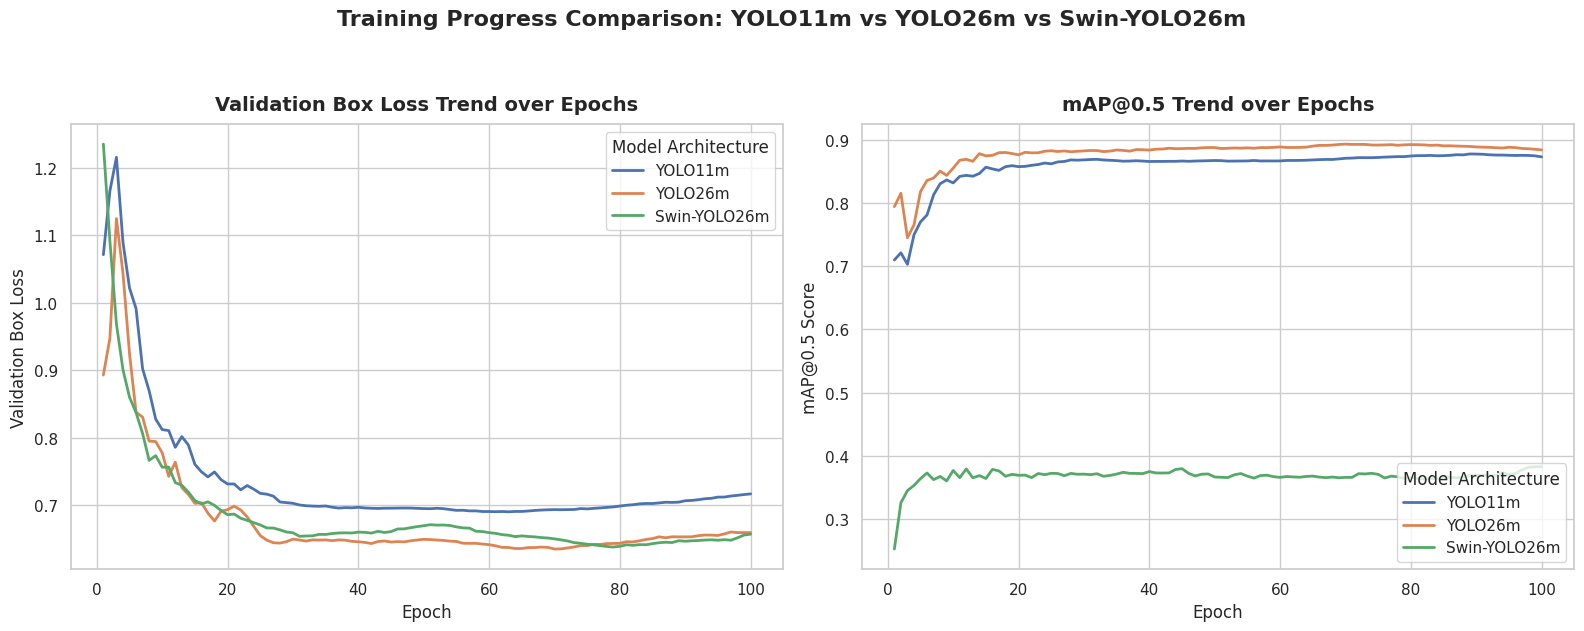

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 파일 경로 및 논문용 모델명 매핑
files = {
    'YOLO11m': '/content/yolo11results.csv',
    'YOLO26m': '/content/yolo26results.csv',
    'Swin-YOLO26m': '/content/swinyolo26results.csv'
}

# 그래프 설정
plt.figure(figsize=(16, 6))
sns.set_theme(style="whitegrid")

ax1 = plt.subplot(1, 2, 1) # 1행 2열 중 첫 번째 (Box Loss)
ax2 = plt.subplot(1, 2, 2) # 1행 2열 중 두 번째 (mAP@0.5)

for model_name, path in files.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()

        # 주요 컬럼 찾기 (버전별 포맷 차이 고려)
        # 에포크 컬럼 (보통 'epoch' 또는 첫 번째 컬럼)
        epoch_col = 'epoch' if 'epoch' in df.columns else df.columns[0]

        # Validation Box Loss 컬럼 찾기
        val_box_loss_col = [c for c in df.columns if 'val' in c.lower() and 'box_loss' in c.lower()]
        if not val_box_loss_col: # 다른 이름으로 저장되어 있을 경우 대비
             val_box_loss_col = [c for c in df.columns if 'box' in c.lower() and 'val' in c.lower()]

        # mAP@50 컬럼 찾기
        map50_col = [c for c in df.columns if 'map50' in c.lower() and '95' not in c]

        # 데이터 플로팅
        if val_box_loss_col and map50_col:
            sns.lineplot(x=df[epoch_col], y=df[val_box_loss_col[0]], label=model_name, ax=ax1, linewidth=2)
            sns.lineplot(x=df[epoch_col], y=df[map50_col[0]], label=model_name, ax=ax2, linewidth=2)
        else:
            print(f"{model_name}의 데이터를 찾을 수 없습니다. 컬럼명: {df.columns.tolist()}")
    else:
        print(f"File not found: {path}")

# 첫 번째 그래프 (Validation Box Loss) 꾸미기
ax1.set_title('Validation Box Loss Trend over Epochs', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Validation Box Loss', fontsize=12)
ax1.legend(title='Model Architecture')

# 두 번째 그래프 (mAP@0.5) 꾸미기
ax2.set_title('mAP@0.5 Trend over Epochs', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('mAP@0.5 Score', fontsize=12)
ax2.legend(title='Model Architecture', loc='lower right')

# 전체 그래프 꾸미기
plt.suptitle('Training Progress Comparison: YOLO11m vs YOLO26m vs Swin-YOLO26m', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

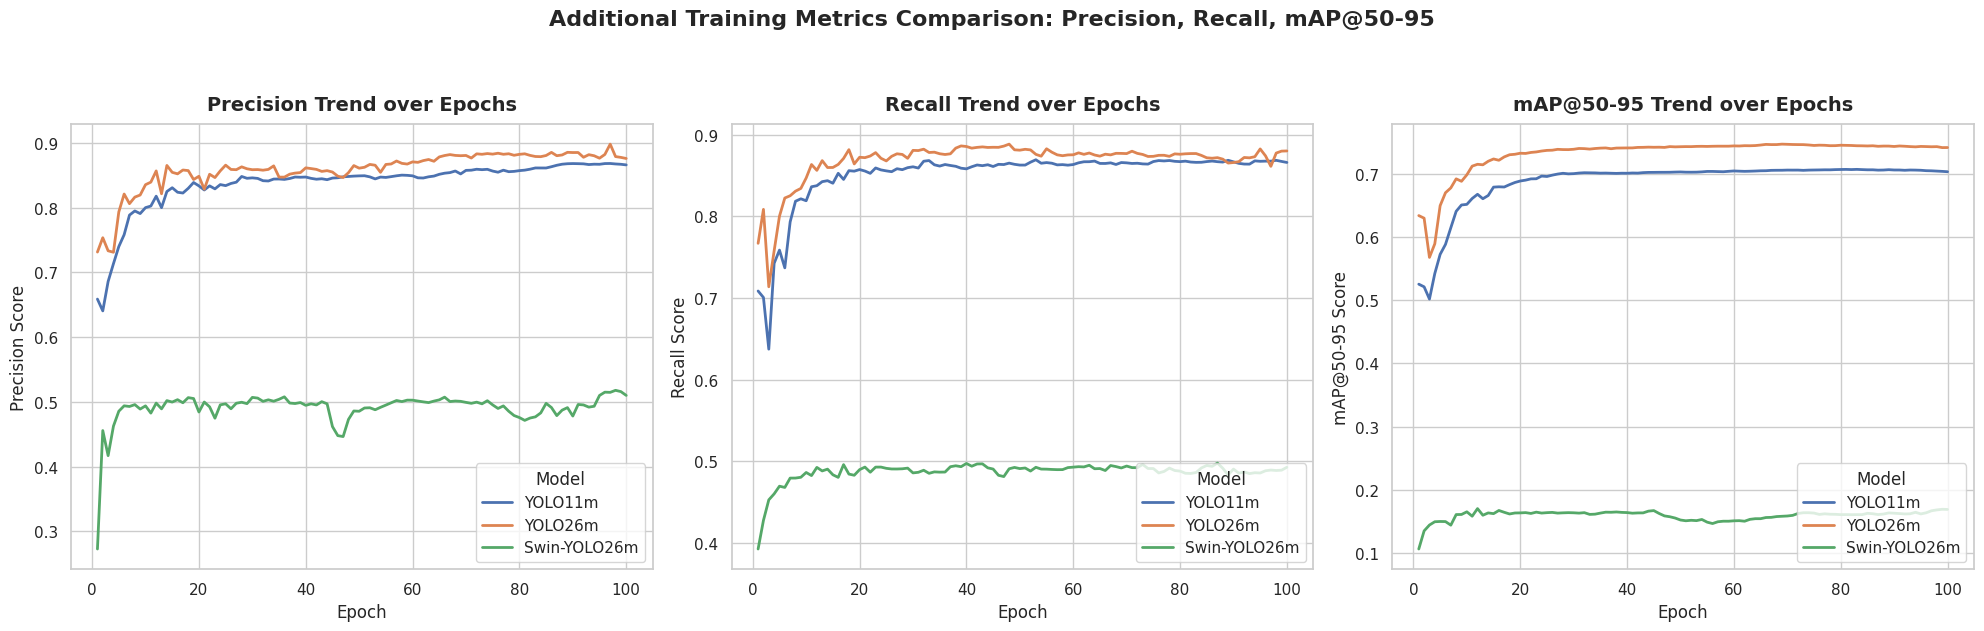

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 파일 경로 및 모델명 매핑
files = {
    'YOLO11m': '/content/yolo11results.csv',
    'YOLO26m': '/content/yolo26results.csv',
    'Swin-YOLO26m': '/content/swinyolo26results.csv'
}

# 그래프 설정 (1행 3열)
plt.figure(figsize=(20, 6))
sns.set_theme(style="whitegrid")

ax1 = plt.subplot(1, 3, 1) # Precision
ax2 = plt.subplot(1, 3, 2) # Recall
ax3 = plt.subplot(1, 3, 3) # mAP@50-95

for model_name, path in files.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()

        # 에포크 컬럼 찾기
        epoch_col = 'epoch' if 'epoch' in df.columns else df.columns[0]

        # 주요 평가지표 컬럼 찾기
        p_col = [c for c in df.columns if 'precision' in c.lower() or 'metrics/p' in c]
        r_col = [c for c in df.columns if 'recall' in c.lower() or 'metrics/r' in c]
        map50_95_col = [c for c in df.columns if 'map50-95' in c.lower() or '0.5:0.95' in c]

        # 데이터 플로팅
        if p_col:
            sns.lineplot(x=df[epoch_col], y=df[p_col[0]], label=model_name, ax=ax1, linewidth=2)
        if r_col:
            sns.lineplot(x=df[epoch_col], y=df[r_col[0]], label=model_name, ax=ax2, linewidth=2)
        if map50_95_col:
            sns.lineplot(x=df[epoch_col], y=df[map50_95_col[0]], label=model_name, ax=ax3, linewidth=2)

# 첫 번째 그래프 (Precision) 꾸미기
ax1.set_title('Precision Trend over Epochs', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Precision Score', fontsize=12)
ax1.legend(title='Model', loc='lower right')

# 두 번째 그래프 (Recall) 꾸미기
ax2.set_title('Recall Trend over Epochs', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Recall Score', fontsize=12)
ax2.legend(title='Model', loc='lower right')

# 세 번째 그래프 (mAP@50-95) 꾸미기
ax3.set_title('mAP@50-95 Trend over Epochs', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('mAP@50-95 Score', fontsize=12)
ax3.legend(title='Model', loc='lower right')

# 전체 그래프 꾸미기
plt.suptitle('Additional Training Metrics Comparison: Precision, Recall, mAP@50-95', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

=== Performance Summary Table ===


,Model,Time (h),mAP@0.5 (%),Precision (%),Recall (%),Box Loss (val)
0,YOLO11m,20.097833,87.542,86.118,86.604,0.70214
1,YOLO26m,27.141278,89.277,88.009,87.701,0.63765
2,Swin-YOLO26m,77.144444,37.902,49.800,49.273,0.73357


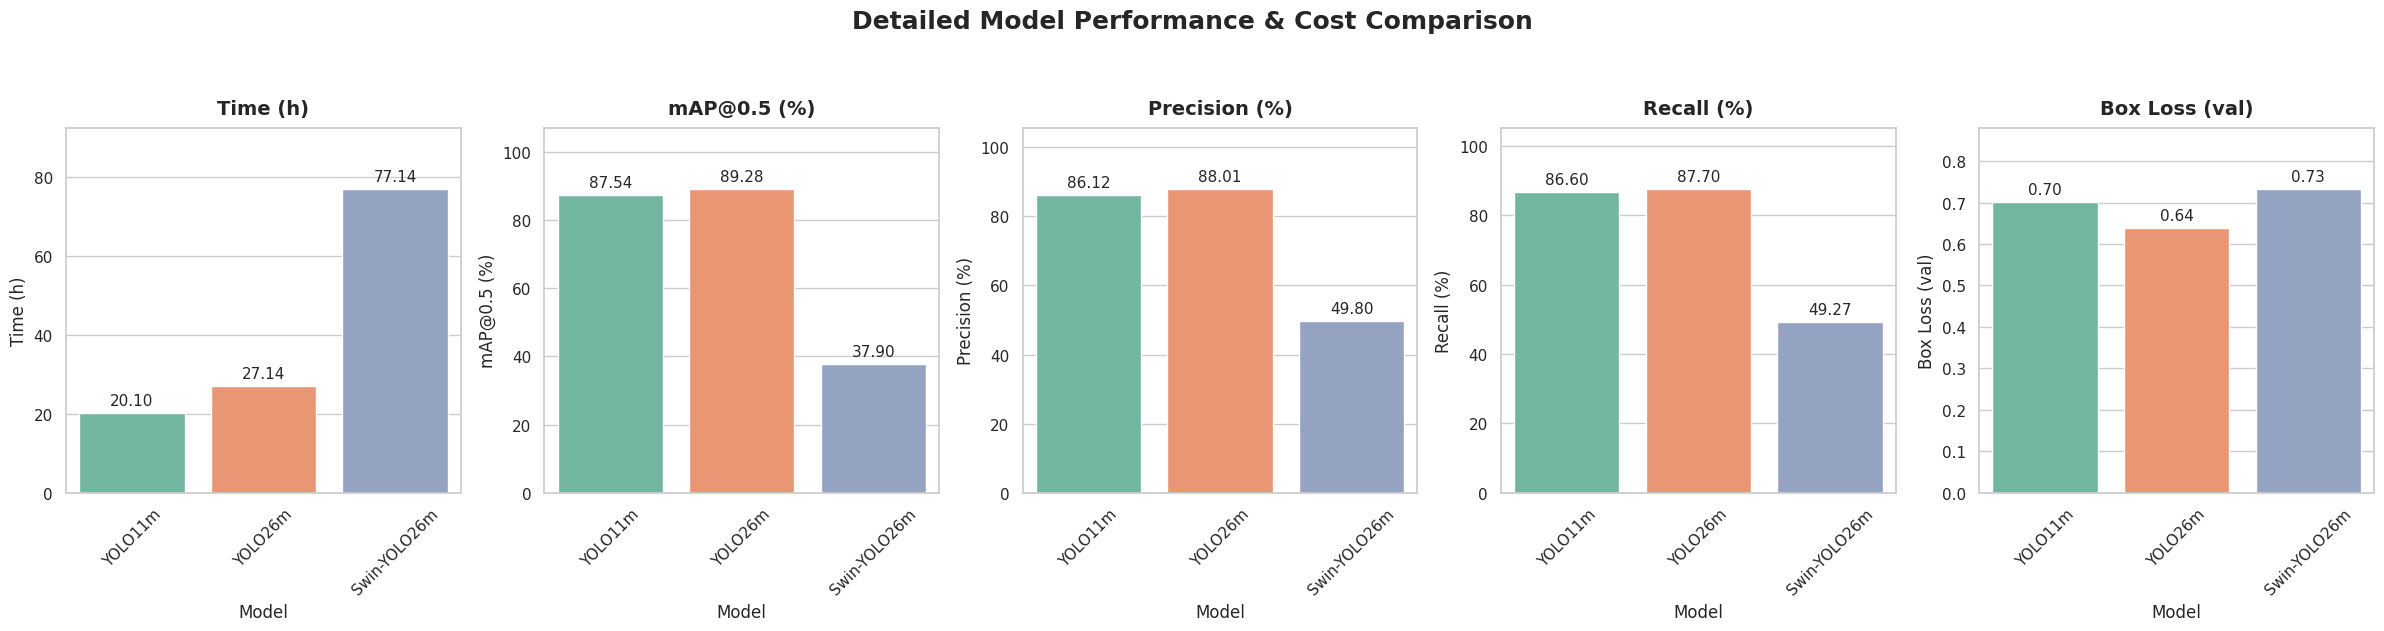

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 파일 경로 및 모델명 매핑
files = {
    'YOLO11m': '/content/yolo11results.csv',
    'YOLO26m': '/content/yolo26results.csv',
    'Swin-YOLO26m': '/content/swinyolo26results.csv'
}

summary_data = []

for model_name, path in files.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()

        # 필요한 컬럼명 찾기
        time_col = [c for c in df.columns if 'time' in c.lower()]
        p_col = [c for c in df.columns if 'precision' in c.lower() or 'metrics/p' in c]
        r_col = [c for c in df.columns if 'recall' in c.lower() or 'metrics/r' in c]
        map50_col = [c for c in df.columns if 'map50' in c.lower() and '95' not in c]
        map50_95_col = [c for c in df.columns if 'map50-95' in c.lower() or '0.5:0.95' in c]
        val_box_loss_col = [c for c in df.columns if 'val' in c.lower() and 'box_loss' in c.lower()]
        if not val_box_loss_col:
            val_box_loss_col = [c for c in df.columns if 'box' in c.lower() and 'val' in c.lower()]

        # 가장 성능이 좋은 Epoch 기준 (mAP@50-95 기준)
        if map50_95_col:
            best_epoch_idx = df[map50_95_col[0]].idxmax()
        else:
            best_epoch_idx = df[map50_col[0]].idxmax() if map50_col else len(df)-1

        # 데이터 추출 및 단위 변환
        # Time: 누적 초(seconds)를 시간(hours)으로 변환
        time_h = (df[time_col[0]].max() / 3600) if time_col else 0

        # 백분율(%) 처리
        map50_val = (df.loc[best_epoch_idx, map50_col[0]] * 100) if map50_col else 0
        p_val = (df.loc[best_epoch_idx, p_col[0]] * 100) if p_col else 0
        r_val = (df.loc[best_epoch_idx, r_col[0]] * 100) if r_col else 0

        # Box Loss
        val_box_loss = df.loc[best_epoch_idx, val_box_loss_col[0]] if val_box_loss_col else 0

        summary_data.append({
            'Model': model_name,
            'Time (h)': time_h,
            'mAP@0.5 (%)': map50_val,
            'Precision (%)': p_val,
            'Recall (%)': r_val,
            'Box Loss (val)': val_box_loss
        })

# 표(Table) 생성 및 출력
summary_df = pd.DataFrame(summary_data)
print("=== Performance Summary Table ===")
display(summary_df)

# 막대 그래프 시각화
if not summary_df.empty:
    sns.set_theme(style="whitegrid")
    metrics_to_plot = ['Time (h)', 'mAP@0.5 (%)', 'Precision (%)', 'Recall (%)', 'Box Loss (val)']

    # 1행 5열의 그래프 생성
    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(24, 6))
    palette = sns.color_palette("Set2", n_colors=len(summary_df['Model'].unique()))

    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i]
        sns.barplot(x='Model', y=metric, hue='Model', data=summary_df, ax=ax, palette=palette, legend=False)

        ax.set_title(f'{metric}', fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel('Model', fontsize=12)
        ax.set_ylabel(metric, fontsize=12)
        ax.tick_params(axis='x', rotation=45)

        # y축 최대값 여유 공간 설정
        max_val = summary_df[metric].max()
        ax.set_ylim(0, max_val * 1.2 if max_val > 0 else 1.0)

        # 막대 위에 수치 텍스트 표시
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(format(height, '.2f'),
                            (p.get_x() + p.get_width() / 2., height),
                            ha = 'center', va = 'center',
                            xytext = (0, 9), textcoords = 'offset points',
                            fontsize=11)

    plt.suptitle('Detailed Model Performance & Cost Comparison', fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()


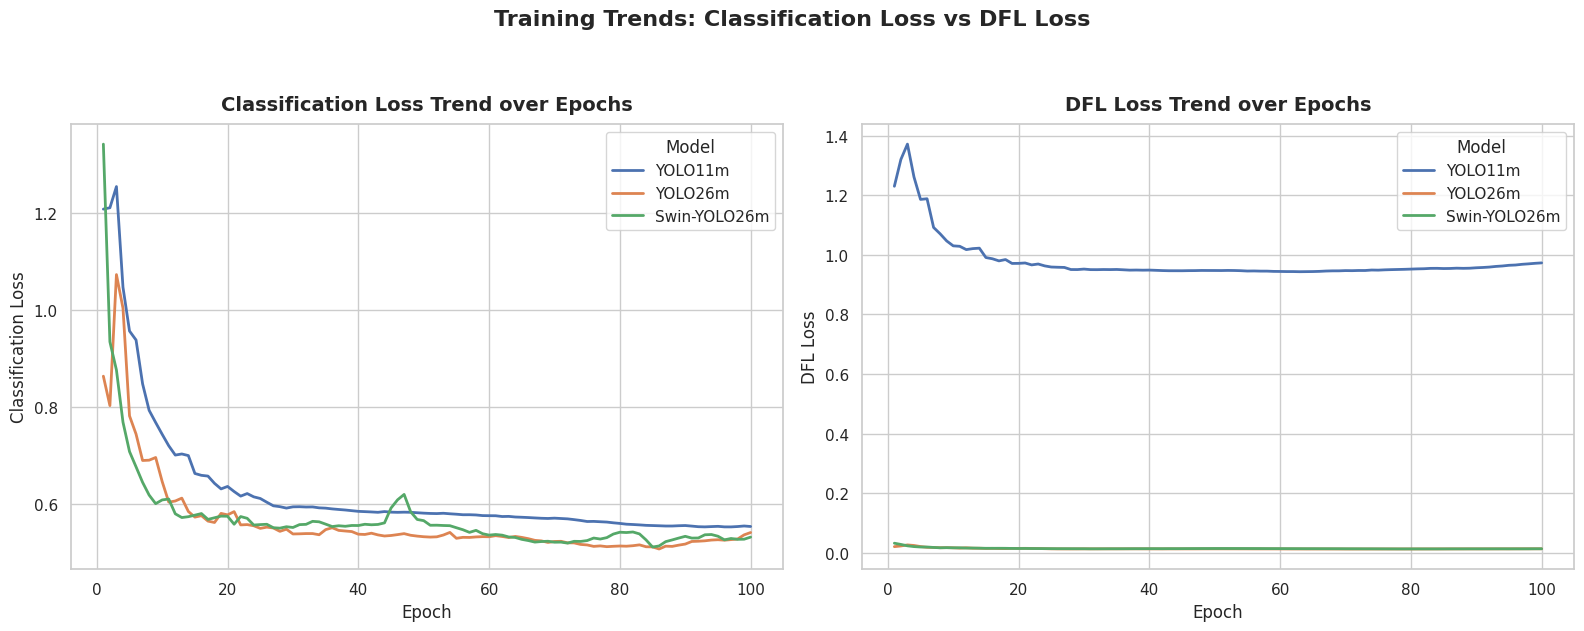

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 파일 경로 및 모델명 매핑
files = {
    'YOLO11m': '/content/yolo11results.csv',
    'YOLO26m': '/content/yolo26results.csv',
    'Swin-YOLO26m': '/content/swinyolo26results.csv'
}

# 그래프 설정 (1행 2열)
plt.figure(figsize=(16, 6))
sns.set_theme(style="whitegrid")

ax1 = plt.subplot(1, 2, 1) # Classification Loss
ax2 = plt.subplot(1, 2, 2) # DFL Loss

for model_name, path in files.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()

        # 에포크 컬럼 찾기
        epoch_col = 'epoch' if 'epoch' in df.columns else df.columns[0]

        # Classification Loss 찾기 (Val Loss 우선, 없으면 Train Loss)
        cls_col = [c for c in df.columns if 'val' in c.lower() and 'cls_loss' in c.lower()]
        if not cls_col:
            cls_col = [c for c in df.columns if 'cls_loss' in c.lower()]

        # DFL Loss 찾기 (Val Loss 우선, 없으면 Train Loss)
        dfl_col = [c for c in df.columns if 'val' in c.lower() and 'dfl_loss' in c.lower()]
        if not dfl_col:
            dfl_col = [c for c in df.columns if 'dfl_loss' in c.lower()]

        # 데이터 플로팅
        if cls_col:
            sns.lineplot(x=df[epoch_col], y=df[cls_col[0]], label=model_name, ax=ax1, linewidth=2)
        if dfl_col:
            sns.lineplot(x=df[epoch_col], y=df[dfl_col[0]], label=model_name, ax=ax2, linewidth=2)

# 첫 번째 그래프 (Classification Loss) 꾸미기
ax1.set_title('Classification Loss Trend over Epochs', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Classification Loss', fontsize=12)
ax1.legend(title='Model')

# 두 번째 그래프 (DFL Loss) 꾸미기
ax2.set_title('DFL Loss Trend over Epochs', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('DFL Loss', fontsize=12)
ax2.legend(title='Model')

# 전체 그래프 꾸미기
plt.suptitle('Training Trends: Classification Loss vs DFL Loss', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()